# Policy Strength and Recidivism

This notebook asks whether states with stronger prison education policies have lower two-year recidivism rates.

**Design:** Cross-sectional. Policy scores come from a 2024 study of state prison education laws and are applied to releases from 2005–2018. All identifying variation is across states, not over time — state fixed effects cannot be included without perfectly absorbing the policy score. With 33 states providing policy data, the effective identifying sample is small regardless of individual-level N.

**Key limitations:**
- Scores are a 2024 snapshot; states may have had different policies during the study window. Measurement error of this form biases estimates toward zero.
- Cross-sectional identification cannot rule out omitted state-level confounders (e.g., incarceration rates, demographics, funding).
- Results are associations, not causal estimates.

**Input:** `data/processed/clean_recidivism.csv`  
**Output:** Policy association model summaries and state-level scatter plot.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../data/processed/clean_recidivism.csv")
PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(exist_ok=True)

POLICY_COLS = [
    "ABE_Literacy",
    "Secondary",
    "Vocational",
    "College",
    "Automatic_Enrollment",
    "School_District",
    "Sentence_Reduction",
]

STATE_ABBR = {
    "Alabama": "AL", "Arizona": "AZ", "California": "CA",
    "Colorado": "CO", "Delaware": "DE", "District of Columbia": "DC",
    "Florida": "FL", "Georgia": "GA", "Illinois": "IL",
    "Indiana": "IN", "Iowa": "IA", "Kentucky": "KY",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT",
    "Nebraska": "NE", "Nevada": "NV", "New Jersey": "NJ",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "Tennessee": "TN",
    "Texas": "TX", "Utah": "UT", "Washington": "WA",
    "Wisconsin": "WI",
}

## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows:    11,547,985
Columns: 26


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,within_2_yrs,tot_arrest_counts,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction,Total_Score,policy_tier
0,A012021000000000001,1,1,2,2011,2011,0.0000,7.0000,1.0000,2.0000,2.0000,0,1.0000,1,Alabama,0,1,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
1,A012021000000000002,1,1,2,2016,2016,2.0000,8.0000,1.0000,2.0000,2.0000,0,NaN,1,Alabama,1,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
2,A012021000000000002,1,3,2,2017,2018,2.0000,8.0000,1.0000,2.0000,2.0000,1,2.0000,1,Alabama,0,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
3,A012021000000000003,1,1,3,2011,2012,2.0000,12.0000,NaN,3.0000,3.0000,0,2.0000,1,Alabama,0,1,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
4,A012021000000000004,1,9,2,2003,2007,4.0000,7.0000,1.0000,1.0000,2.0000,2,3.0000,1,Alabama,0,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low


## 3. Policy Overview

Policy scores are state-level constants. Every inmate released from the same state carries the same score regardless of release year. The table below shows one row per state sorted by score. DC is the only state missing a score and will be dropped from all models.

In [3]:
policy_state = (
    df[["STATE_NAME", "Total_Score", "policy_tier"] + POLICY_COLS]
    .drop_duplicates("STATE_NAME")
    .sort_values("Total_Score", ascending=False)
    .reset_index(drop=True)
)

print(f"States with policy data: {policy_state['Total_Score'].notna().sum()} / {len(policy_state)}")
print(f"\nTotal_Score distribution:")
print(policy_state["Total_Score"].describe().to_string())
print(f"\nPolicy tier counts:")
print(policy_state["policy_tier"].value_counts().to_string())
policy_state

States with policy data: 33 / 34

Total_Score distribution:
count   33.0000
mean     3.5455
std      1.4313
min      1.0000
25%      2.7500
50%      3.2500
75%      4.5000
max      6.5000

Policy tier counts:
policy_tier
Medium    14
Low       14
High       5


,STATE_NAME,Total_Score,policy_tier,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction
0,Ohio,6.5000,High,1.0000,1.0000,0.5000,1.0000,1.0000,1.0000,1.0000
1,California,6.2500,High,0.7500,0.7500,0.7500,1.0000,1.0000,1.0000,1.0000
2,Iowa,5.7500,High,1.0000,1.0000,1.0000,0.7500,1.0000,0.0000,1.0000
3,Rhode Island,5.5000,High,1.0000,1.0000,1.0000,0.5000,0.0000,1.0000,1.0000
4,Illinois,5.2500,High,0.7500,0.2500,0.5000,0.7500,1.0000,1.0000,1.0000
5,North Dakota,5.0000,Medium,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
6,New York,5.0000,Medium,0.7500,0.5000,0.7500,1.0000,0.0000,1.0000,1.0000
7,New Jersey,4.7500,Medium,0.5000,1.0000,0.7500,0.5000,1.0000,0.0000,1.0000
8,Texas,4.5000,Medium,0.5000,0.5000,0.2500,0.2500,1.0000,1.0000,1.0000
9,South Carolina,4.5000,Medium,1.0000,0.0000,0.5000,0.0000,1.0000,1.0000,1.0000


## 4. Analysis Sample

Apply the same sample restrictions as the DID notebook: exclude extreme sentence lengths (categories 4–6) and ages above category 5, and restrict to release years 2005–2018.

In [4]:
df_reg = df[
    ~df["SENTLGTH"].isin([4, 5, 6])
    & (df["AGEADMIT"] <= 5)
    & (df["RELEASEYR"] >= 2005)
    & (df["RELEASEYR"] <= 2018)
].copy()

df_model = df_reg.dropna(
    subset=[
        "within_2_yrs", "Total_Score", "STATE_NAME", "RELEASEYR",
        "OFFGENERAL", "SEX", "AGEADMIT", "SENTLGTH",
    ]
)

print(f"Full data:    {len(df):,}")
print(f"Reg sample:   {len(df_reg):,}")
print(f"Model sample: {len(df_model):,}")
print(f"States:       {df_model['STATE_NAME'].nunique()}  (DC dropped — missing policy score)")

Full data:    11,547,985
Reg sample:   6,414,037
Model sample: 6,361,584
States:       33  (DC dropped — missing policy score)


## 5. Total Score Model

Regress recidivism on `Total_Score` with year fixed effects and individual controls. Standard errors are clustered by state.

Despite 6M+ individual observations, the effective identifying sample is the ~33 state clusters. Clustered p-values with few clusters tend to be anti-conservative, so the threshold for claiming significance should be treated conservatively.

In [5]:
model_score = smf.ols(
    "within_2_yrs ~ Total_Score"
    " + C(RELEASEYR)"
    " + C(OFFGENERAL)"
    " + C(SEX)"
    " + AGEADMIT"
    " + SENTLGTH",
    data=df_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_model["STATE_NAME"]})

print(model_score.summary())
print(f"\nTotal_Score: coef={model_score.params['Total_Score']:.4f}  se={model_score.bse['Total_Score']:.4f}  p={model_score.pvalues['Total_Score']:.4f}")

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     718.7
Date:                Sat, 02 May 2026   Prob (F-statistic):           4.00e-37
Time:                        00:41:37   Log-Likelihood:            -3.5753e+06
No. Observations:             6361584   AIC:                         7.151e+06
Df Residuals:                 6361561   BIC:                         7.151e+06
Df Model:                          22                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3010 

## 6. Policy Components Model

Replace `Total_Score` with its seven component dimensions. The components are sub-scores from the same 2024 scoring rubric, so they are not independent signals — they share the same measurement concerns as the composite. This is a decomposition, not an independent test.

In [6]:
model_components = smf.ols(
    "within_2_yrs ~ ABE_Literacy + Secondary + Vocational + College"
    " + Automatic_Enrollment + School_District + Sentence_Reduction"
    " + C(RELEASEYR)"
    " + C(OFFGENERAL)"
    " + C(SEX)"
    " + AGEADMIT"
    " + SENTLGTH",
    data=df_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_model["STATE_NAME"]})

print(model_components.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                 1.029e+04
Date:                Sat, 02 May 2026   Prob (F-statistic):           3.64e-56
Time:                        00:42:27   Log-Likelihood:            -3.5644e+06
No. Observations:             6361584   AIC:                         7.129e+06
Df Residuals:                 6361555   BIC:                         7.129e+06
Df Model:                          28                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3463 

## 7. State-Year Panel

Collapse the data to state × release-year cells and estimate a weighted least squares model. Each observation is one state in one year, weighted by the number of releases in that cell. This makes the actual sample size for inference explicit and gives more influence to larger release cohorts.

Because policy scores do not vary within a state over time, the identification here remains cross-sectional — state fixed effects would again absorb all policy variation.

In [7]:
df_state_year = (
    df_model.groupby(["STATE_NAME", "RELEASEYR"])
    .agg(
        recid_rate=("within_2_yrs", "mean"),
        n_inmates=("within_2_yrs", "size"),
        Total_Score=("Total_Score", "first"),
        ABE_Literacy=("ABE_Literacy", "first"),
        Secondary=("Secondary", "first"),
        Vocational=("Vocational", "first"),
        College=("College", "first"),
        Automatic_Enrollment=("Automatic_Enrollment", "first"),
        School_District=("School_District", "first"),
        Sentence_Reduction=("Sentence_Reduction", "first"),
    )
    .reset_index()
)

print(f"State-year cells: {len(df_state_year):,}")
print(f"States:           {df_state_year['STATE_NAME'].nunique()}")
print(f"Years:            {sorted(df_state_year['RELEASEYR'].unique())}")
df_state_year.head()

State-year cells: 439
States:           33
Years:            [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


,STATE_NAME,RELEASEYR,recid_rate,n_inmates,Total_Score,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction
0,Alabama,2007,0.1921,7121,1.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000
1,Alabama,2008,0.2057,7914,1.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000
2,Alabama,2009,0.1916,8537,1.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000
3,Alabama,2010,0.2009,8639,1.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000
4,Alabama,2011,0.2060,8031,1.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000


In [8]:
model_state_year = smf.wls(
    "recid_rate ~ Total_Score + C(RELEASEYR)",
    data=df_state_year,
    weights=df_state_year["n_inmates"],
).fit(cov_type="cluster", cov_kwds={"groups": df_state_year["STATE_NAME"]})

print(model_state_year.summary())
print(f"\nTotal_Score: coef={model_state_year.params['Total_Score']:.4f}  se={model_state_year.bse['Total_Score']:.4f}  p={model_state_year.pvalues['Total_Score']:.4f}")

                            WLS Regression Results                            
Dep. Variable:             recid_rate   R-squared:                       0.403
Model:                            WLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     83.90
Date:                Sat, 02 May 2026   Prob (F-statistic):           3.84e-21
Time:                        00:42:41   Log-Likelihood:                 514.63
No. Observations:                 439   AIC:                            -999.3
Df Residuals:                     424   BIC:                            -938.0
Df Model:                          14                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2663 

## 8. Visualization

The scatter below shows each state's average recidivism rate against its policy score — the actual cross-state identifying variation. Bubble size is proportional to the number of releases; color indicates policy tier. The dashed line is an unweighted OLS fit.

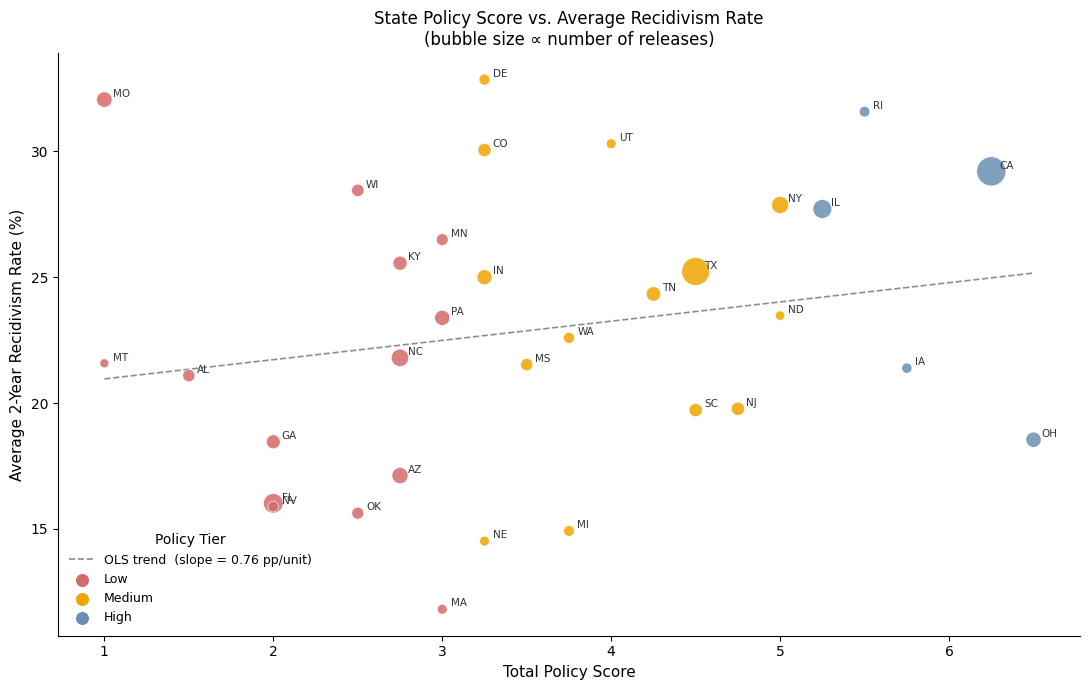

In [9]:
state_summary = (
    df_model.groupby("STATE_NAME")
    .agg(
        recid_rate=("within_2_yrs", "mean"),
        n_inmates=("within_2_yrs", "size"),
        total_score=("Total_Score", "first"),
        policy_tier=("policy_tier", "first"),
    )
    .reset_index()
)
state_summary["abbr"] = state_summary["STATE_NAME"].map(STATE_ABBR).fillna(state_summary["STATE_NAME"].str[:3])

tier_colors = {"Low": "#d46a6a", "Medium": "#f0a500", "High": "#6b8fb3"}
colors = state_summary["policy_tier"].map(tier_colors).fillna("#aaaaaa")
sizes = state_summary["n_inmates"] / state_summary["n_inmates"].max() * 400 + 40

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    state_summary["total_score"],
    state_summary["recid_rate"] * 100,
    c=colors,
    s=sizes,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=3,
)

for _, row in state_summary.iterrows():
    ax.annotate(
        row["abbr"],
        (row["total_score"], row["recid_rate"] * 100),
        textcoords="offset points",
        xytext=(6, 2),
        fontsize=7.5,
        color="#333333",
    )

# OLS trend line on non-missing states only
valid = state_summary.dropna(subset=["total_score"])
m, b = np.polyfit(valid["total_score"], valid["recid_rate"] * 100, 1)
x_range = np.linspace(valid["total_score"].min(), valid["total_score"].max(), 100)
ax.plot(x_range, m * x_range + b, "k--", linewidth=1.2, alpha=0.45, label=f"OLS trend  (slope = {m:.2f} pp/unit)")

for tier, color in tier_colors.items():
    ax.scatter([], [], c=color, s=70, label=tier)

ax.set_xlabel("Total Policy Score", fontsize=11)
ax.set_ylabel("Average 2-Year Recidivism Rate (%)", fontsize=11)
ax.set_title("State Policy Score vs. Average Recidivism Rate\n(bubble size ∝ number of releases)", fontsize=12)
ax.legend(title="Policy Tier", frameon=False, fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "policy_score_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Summary

In [10]:
summary_results = pd.DataFrame({
    "model": [
        "Individual-level OLS (Total_Score)",
        "State-year WLS (Total_Score)",
    ],
    "coef": [
        model_score.params["Total_Score"],
        model_state_year.params["Total_Score"],
    ],
    "clustered_se": [
        model_score.bse["Total_Score"],
        model_state_year.bse["Total_Score"],
    ],
    "p_value": [
        model_score.pvalues["Total_Score"],
        model_state_year.pvalues["Total_Score"],
    ],
    "n_obs": [int(model_score.nobs), int(model_state_year.nobs)],
    "n_states": [
        df_model["STATE_NAME"].nunique(),
        df_state_year["STATE_NAME"].nunique(),
    ],
})
print("Total Score models:")
summary_results

Total Score models:


,model,coef,clustered_se,p_value,n_obs,n_states
0,Individual-level OLS (Total_Score),0.0108,0.0066,0.1031,6361584,33
1,State-year WLS (Total_Score),0.0102,0.0069,0.1370,439,33


In [11]:
components_table = pd.DataFrame({
    "component": POLICY_COLS,
    "coef": [model_components.params[c] for c in POLICY_COLS],
    "clustered_se": [model_components.bse[c] for c in POLICY_COLS],
    "p_value": [model_components.pvalues[c] for c in POLICY_COLS],
})
print("Policy components (individual-level OLS):")
components_table

Policy components (individual-level OLS):


,component,coef,clustered_se,p_value
0,ABE_Literacy,0.0297,0.0364,0.4153
1,Secondary,0.0302,0.0272,0.2675
2,Vocational,-0.0139,0.0347,0.6898
3,College,0.0338,0.0269,0.2088
4,Automatic_Enrollment,-0.0214,0.0136,0.1163
5,School_District,0.0177,0.0204,0.3860
6,Sentence_Reduction,-0.0276,0.0301,0.3590


### Takeaway

Neither `Total_Score` nor any individual policy component shows a statistically significant association with recidivism across specifications. The state-year panel reaches the same conclusion with a more honest sample size.

Three interpretations are consistent with this null:
1. **Underpowered.** Cross-sectional identification across ~33 states cannot detect a modest effect even at individual-level N in the millions.
2. **Measurement error.** The 2024 policy scores may not accurately represent each state's policies during 2005–2018, attenuating any true association toward zero.
3. **No effect.** State-level education policy quality, as scored here, does not independently predict recidivism after controlling for year trends.